# 02 — Q2: Price-per-sqft trend (2012-2026)

**Question:** What's the price-per-sqft trend across 08648 Lawrenceville vs. 08534 Pennington, 08619 Hamilton, 08550 Princeton Junction?

**Data:** `redfin_monthly` table (676 rows, 2012-01 to 2026-01).

**Output:** time series chart + CAGR (compound annual growth rate) per zip.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 10

DB = Path.cwd().parent / 'data' / 'clean' / 'housing.db'
ZIP_NAMES = {
    '08534': 'Pennington',
    '08550': 'Princeton Jct',
    '08619': 'Hamilton',
    '08648': 'Lawrenceville',
}

In [2]:
# Pull annual median PPSF per zip — average the quarterly observations
conn = sqlite3.connect(DB)
ppsf = pd.read_sql("""
    SELECT
        zip,
        CAST(strftime('%Y', period_begin) AS INTEGER) AS year,
        AVG(median_ppsf) AS median_ppsf,
        AVG(median_sale_price) AS median_sale_price
    FROM redfin_monthly
    WHERE median_ppsf IS NOT NULL
    GROUP BY zip, year
    ORDER BY zip, year
""", conn)
conn.close()

ppsf['name'] = ppsf['zip'].map(ZIP_NAMES)
ppsf.head()

,zip,year,median_ppsf,median_sale_price,name
0,08534,2012,175.843655,344779.166667,Pennington
1,08534,2013,186.473325,358827.083333,Pennington
2,08534,2014,190.240811,378325.000000,Pennington
3,08534,2015,192.500299,399958.333333,Pennington
4,08534,2016,193.492975,390000.000000,Pennington


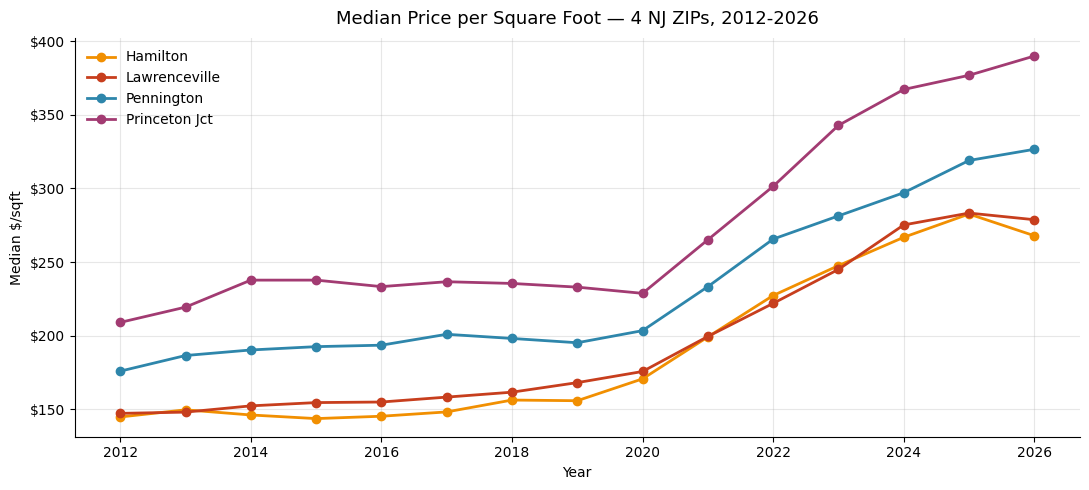

In [3]:
# One line per zip, x=year, y=median PPSF
fig, ax = plt.subplots()
colors = {'Pennington': '#2E86AB', 'Princeton Jct': '#A23B72', 'Hamilton': '#F18F01', 'Lawrenceville': '#C73E1D'}

for name, grp in ppsf.groupby('name'):
    ax.plot(grp['year'], grp['median_ppsf'], marker='o', label=name, color=colors.get(name, 'gray'), linewidth=2)

ax.set_title('Median Price per Square Foot — 4 NJ ZIPs, 2012-2026', fontsize=13, pad=10)
ax.set_xlabel('Year')
ax.set_ylabel('Median $/sqft')
ax.legend(loc='upper left', frameon=False)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
plt.tight_layout()
plt.show()

In [4]:
# CAGR = compound annual growth rate. How fast each zip's PPSF grew per year on average.
# Formula: (end / start) ** (1 / years) - 1
cagr_rows = []
for name, grp in ppsf.groupby('name'):
    grp = grp.sort_values('year')
    start = grp['median_ppsf'].iloc[0]
    end   = grp['median_ppsf'].iloc[-1]
    years = grp['year'].iloc[-1] - grp['year'].iloc[0]
    cagr  = (end / start) ** (1 / years) - 1
    cagr_rows.append({
        'name': name,
        'start_year': int(grp['year'].iloc[0]),
        'start_ppsf': round(start, 2),
        'end_year':   int(grp['year'].iloc[-1]),
        'end_ppsf':   round(end, 2),
        'total_growth_pct': round((end/start - 1) * 100, 1),
        'cagr_pct':   round(cagr * 100, 2),
    })

cagr_df = pd.DataFrame(cagr_rows).sort_values('cagr_pct', ascending=False)
cagr_df

,name,start_year,start_ppsf,end_year,end_ppsf,total_growth_pct,cagr_pct
1,Lawrenceville,2012,147.16,2026,278.77,89.4,4.67
3,Princeton Jct,2012,208.98,2026,390.01,86.6,4.56
2,Pennington,2012,175.84,2026,326.61,85.7,4.52
0,Hamilton,2012,144.72,2026,267.90,85.1,4.50


## Finding — Q2

Over 2012-2026, all four ZIPs grew at remarkably similar rates — between
**4.50% and 4.67% compound annual growth**. The spread is only 0.17
percentage points, which tells us **Mercer County moves as one housing
market**, not four separate ones.

**Lawrenceville (08648) actually led the pack** at **4.67% CAGR**, rising
from $147.16/sqft in 2012 to $278.77/sqft in 2026 — an **89.4% total
gain** over 14 years. Hamilton grew slowest at 4.50% but still nearly
doubled (+85.1%).

Ranking by CAGR:
| Rank | ZIP | Name | 2012 → 2026 $/sqft | Total growth | CAGR |
|---|---|---|---|---|---|
| 1 | 08648 | Lawrenceville | $147 → $279 | +89.4% | 4.67% |
| 2 | 08550 | Princeton Jct | $209 → $390 | +86.6% | 4.56% |
| 3 | 08534 | Pennington | $176 → $327 | +85.7% | 4.52% |
| 4 | 08619 | Hamilton | $145 → $268 | +85.1% | 4.50% |

**Implication for our move:** Buying in Lawrenceville means buying into
a coherent regional market with steady, predictable appreciation — not
a frothy bubble or a stagnant zone. There is **no "better" ZIP on price
growth alone** within this 4-ZIP set. Differentiation between
neighborhoods will come from the other questions: schools (Q1), commute
(Q3), and tax burden (Q4).